# **Statistical Analysis of Data**

In [9]:
# ==========================================
# CELL 1: SETUP & DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import io
from collections import Counter
from google.colab import files

# Create output directories for your report
BASE_DIR = Path('.').resolve()
PLOT_DIR = BASE_DIR / 'outputs' / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style="whitegrid")

# Upload and load the file
print("Please upload your English-Urdu dataset (Excel or CSV):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

if filename.endswith(('.xlsx', '.xls')):
    df = pd.read_excel(io.BytesIO(uploaded[filename]))
else:
    df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Identify text columns
text_cols = df.select_dtypes(include=['object']).columns
eng_col, urdu_col = text_cols[0], text_cols[1]

print(f"\n✓ Dataset loaded successfully: {filename}")
print(f"Initial Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Please upload your English-Urdu dataset (Excel or CSV):


Saving english_to_urdu_dataset.xlsx to english_to_urdu_dataset (3).xlsx

✓ Dataset loaded successfully: english_to_urdu_dataset (3).xlsx
Initial Shape: 9,103 rows × 2 columns


In [18]:

print("\n" + "=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Column names: {list(df.columns)}")
print(f"Total number of rows: {len(df):,}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nFirst 5 rows:")
print(df.head())


DATASET OVERVIEW
Dataset loaded successfully!
Shape: (9103, 2)
Column names: ['eng', 'urdu']
Total number of rows: 9,103
Memory usage: 5.06 MB

First 5 rows:
                                                                                        eng  \
0         the book of the generation of jesus christ  the son of david  the son of abraham    
1       abraham begat isaac  and isaac begat jacob  and jacob begat judas and his brethren    
2  and judas begat phares and zara of thamar  and phares begat esrom  and esrom begat aram    
3            and aram begat aminadab  and aminadab begat naasson  and naasson begat salmon    
4       and salmon begat booz of rachab  and booz begat obed of ruth  and obed begat jesse    

                                                                                                  urdu  
0                                                            یسوع مسیح ابن داود ابن ابرہام کا نسب نامہ  
1  ابراہام سے اضحاق پیدا ہوا اور اضحاق سے یعقوب پیدا ہوا اور

In [17]:
# Check for duplicate rows
print("\n" + "=" * 80)
print("DUPLICATE ROWS ANALYSIS")
print("=" * 80)
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count:,}")
print(f"Percentage of duplicates: {(duplicate_count / len(df)) * 100:.2f}%")

if duplicate_count > 0:
    print("\nSample duplicate rows:")
    pd.set_option('display.max_colwidth', 80)
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))
    pd.set_option('display.max_colwidth', 100)


DUPLICATE ROWS ANALYSIS
Total duplicate rows: 9
Percentage of duplicates: 0.10%

Sample duplicate rows:
                                                                                  eng  \
320                         and blessed is he  whosoever shall not be offended in me    
2073                        and blessed is he  whosoever shall not be offended in me    
179   for every one that asketh receiveth  and he that seeketh findeth  and to him...   
2270  for every one that asketh receiveth  and he that seeketh findeth  and to him...   
5221  grace be unto you  and peace  from god our father  and from the lord jesus c...   
6218  grace be unto you  and peace  from god our father  and from the lord jesus c...   
7601       he that hath an ear  let him hear what the spirit saith unto the churches    
7607       he that hath an ear  let him hear what the spirit saith unto the churches    
7614       he that hath an ear  let him hear what the spirit saith unto the churches    
7623 

In [10]:
# ==========================================
# CELL 2: DEEP PROFILING & CLEANING
# ==========================================
print("=" * 50)
print("DATA CLEANING & DUPLICATE ANALYSIS")
print("=" * 50)

# 1. Missing Values
missing_data = df.isnull().sum()
print("Missing Values:")
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "✓ No missing values found!")

# 2. Duplicate Analysis
exact_dupes = df.duplicated().sum()
source_dupes = df.duplicated(subset=[eng_col]).sum() - exact_dupes
target_dupes = df.duplicated(subset=[urdu_col]).sum() - exact_dupes

print("\nDuplicate Breakdown:")
print(f"  - Exact Duplicate Pairs: {exact_dupes:,}")
print(f"  - Conflicting (Same English, different Urdu): {source_dupes:,}")
print(f"  - Converging (Different English, same Urdu): {target_dupes:,}")

# 3. Apply Cleaning
# We drop missing values and exact duplicates.
# You may decide to drop conflicting dupes later in Task 1.
df_clean = df.dropna().drop_duplicates().copy()
print(f"\n✓ Shape after strict cleaning: {df_clean.shape[0]:,} rows")

DATA CLEANING & DUPLICATE ANALYSIS
Missing Values:
urdu    1
dtype: int64

Duplicate Breakdown:
  - Exact Duplicate Pairs: 9
  - Conflicting (Same English, different Urdu): 246
  - Converging (Different English, same Urdu): 21

✓ Shape after strict cleaning: 9,093 rows


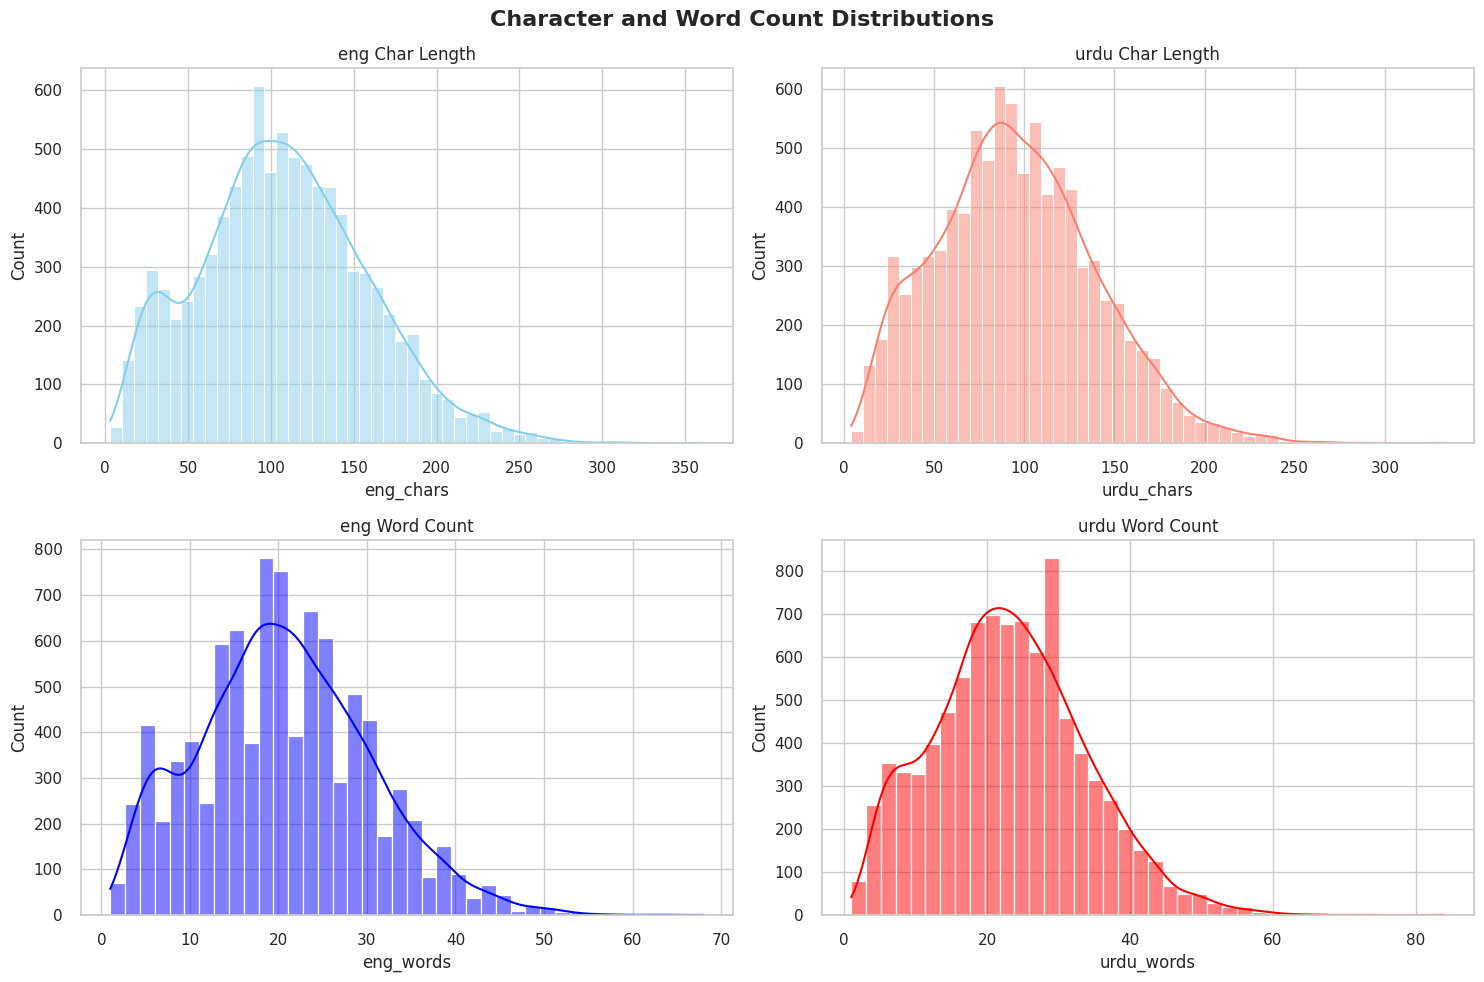

In [11]:
# ==========================================
# CELL 3: SEQUENCE LENGTH DISTRIBUTIONS
# ==========================================
# Calculate character and word counts
df_clean['eng_chars'] = df_clean[eng_col].astype(str).str.len()
df_clean['urdu_chars'] = df_clean[urdu_col].astype(str).str.len()
df_clean['eng_words'] = df_clean[eng_col].astype(str).str.split().str.len()
df_clean['urdu_words'] = df_clean[urdu_col].astype(str).str.split().str.len()

# Plotting Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Character and Word Count Distributions', fontsize=16, fontweight='bold')

sns.histplot(df_clean['eng_chars'], bins=50, ax=axes[0, 0], color='skyblue', kde=True).set_title(f'{eng_col} Char Length')
sns.histplot(df_clean['urdu_chars'], bins=50, ax=axes[0, 1], color='salmon', kde=True).set_title(f'{urdu_col} Char Length')
sns.histplot(df_clean['eng_words'], bins=40, ax=axes[1, 0], color='blue', kde=True).set_title(f'{eng_col} Word Count')
sns.histplot(df_clean['urdu_words'], bins=40, ax=axes[1, 1], color='red', kde=True).set_title(f'{urdu_col} Word Count')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'distribution_dashboard.png', dpi=150)
plt.show()

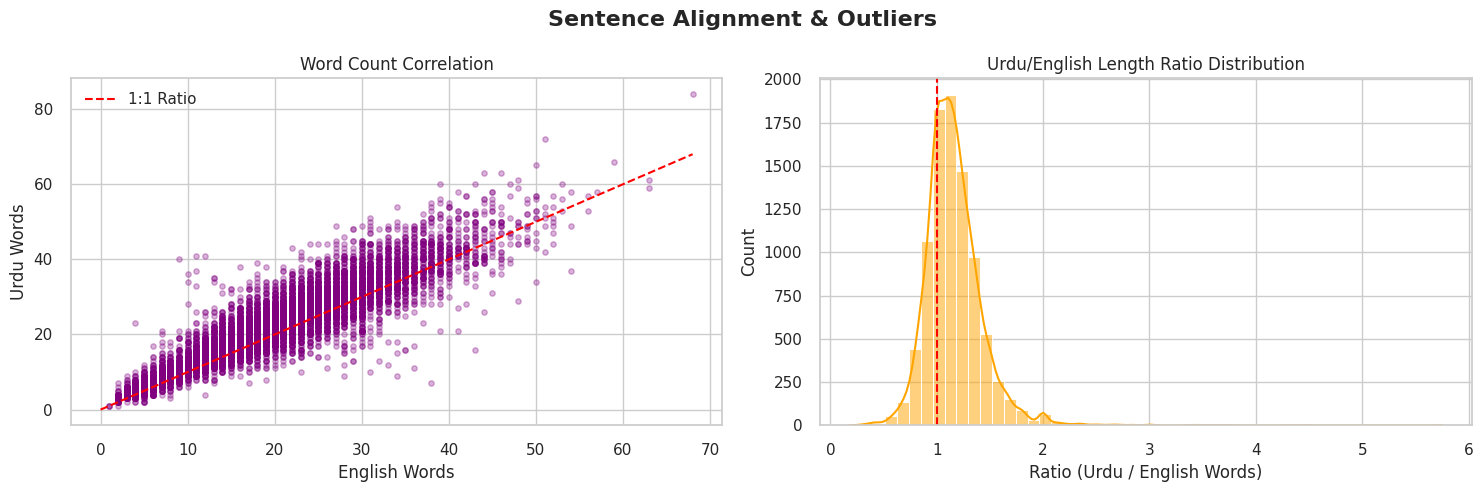


PERCENTILE ANALYSIS (FOR PADDING DECISIONS)
Use this table to justify your max sequence length in Task 4:
Percentile  Eng Words  Urdu Words
      50th       20.0        23.0
      75th       27.0        30.0
      90th       33.0        37.0
      95th       37.4        41.0
      99th       45.0        50.0


In [12]:
# ==========================================
# CELL 4: ALIGNMENT & PADDING PERCENTILES
# ==========================================
# Avoid division by zero
df_clean = df_clean[(df_clean['eng_words'] > 0) & (df_clean['urdu_words'] > 0)]
df_clean['length_ratio'] = df_clean['urdu_words'] / df_clean['eng_words']

# Alignment Dashboard
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Sentence Alignment & Outliers', fontsize=16, fontweight='bold')

# Scatter Plot
axes[0].scatter(df_clean['eng_words'], df_clean['urdu_words'], alpha=0.3, s=15, color='purple')
axes[0].plot([0, df_clean['eng_words'].max()], [0, df_clean['eng_words'].max()], color='red', linestyle='--', label='1:1 Ratio')
axes[0].set_title('Word Count Correlation')
axes[0].set_xlabel('English Words')
axes[0].set_ylabel('Urdu Words')
axes[0].legend()

# Ratio Distribution
sns.histplot(df_clean['length_ratio'], bins=50, ax=axes[1], color='orange', kde=True)
axes[1].axvline(x=1.0, color='red', linestyle='--')
axes[1].set_title('Urdu/English Length Ratio Distribution')
axes[1].set_xlabel('Ratio (Urdu / English Words)')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'alignment_dashboard.png', dpi=150)
plt.show()

# Padding Percentiles (For Task 4)
print("\n" + "=" * 50)
print("PERCENTILE ANALYSIS (FOR PADDING DECISIONS)")
print("=" * 50)
percentiles = [0.5, 0.75, 0.90, 0.95, 0.99]
percentile_df = pd.DataFrame({
    'Percentile': [f"{int(p*100)}th" for p in percentiles],
    'Eng Words': df_clean['eng_words'].quantile(percentiles).values,
    'Urdu Words': df_clean['urdu_words'].quantile(percentiles).values
})
print("Use this table to justify your max sequence length in Task 4:")
print(percentile_df.to_string(index=False))

In [13]:
# ==========================================
# CELL 5: CHARACTER SET EXTRACTION
# ==========================================
print("=" * 50)
print("CHARACTER SET ANALYSIS (FOR TASK 1 NORMALIZATION)")
print("=" * 50)

def get_unique_characters(text_series):
    # Joins all text and finds unique characters
    return sorted(list(set("".join(text_series.astype(str).tolist()))))

eng_unique_chars = get_unique_characters(df_clean[eng_col])
urdu_unique_chars = get_unique_characters(df_clean[urdu_col])

print(f"Unique English Characters ({len(eng_unique_chars)}):")
print(''.join(eng_unique_chars))

print(f"\nUnique Urdu Characters ({len(urdu_unique_chars)}):")
print(''.join(urdu_unique_chars))

# Look for digits specifically in Urdu
urdu_digits = [c for c in urdu_unique_chars if c.isdigit()]
print(f"\nDigits found in Urdu text: {urdu_digits}")

CHARACTER SET ANALYSIS (FOR TASK 1 NORMALIZATION)
Unique English Characters (81):
 !"%',-.01235789:?ABCDEFGHIJKLMNOPRSTUVWXYabcdefghijklmnopqrstuvwxyzºآاتجرلمنکھے۔

Unique Urdu Characters (104):
 !"#&()-./0123578:ABCFKY[]_abceghilnortu،؟ءآأؤئابتثجحخدذرزسشصضطظعغفقلمنوئًُِّْ٘ٹپچڈڑژکگںھہۃیےۓ۔۰۱۲۳۵۷۸۹

Digits found in Urdu text: ['0', '1', '2', '3', '5', '7', '8', '۰', '۱', '۲', '۳', '۵', '۷', '۸', '۹']


VOCABULARY ANALYSIS (FOR TASK 3)

--- English Vocabulary Stats ---
Total Tokens (running words): 187,490
Unique Types (Vocab Size): 7,156
Singletons (Freq=1): 2,618 (36.6% of vocab)
Vocabulary size needed to cover 95% of text: 2,170 words

--- Urdu Vocabulary Stats ---
Total Tokens (running words): 210,495
Unique Types (Vocab Size): 8,111
Singletons (Freq=1): 3,258 (40.2% of vocab)
Vocabulary size needed to cover 95% of text: 2,345 words


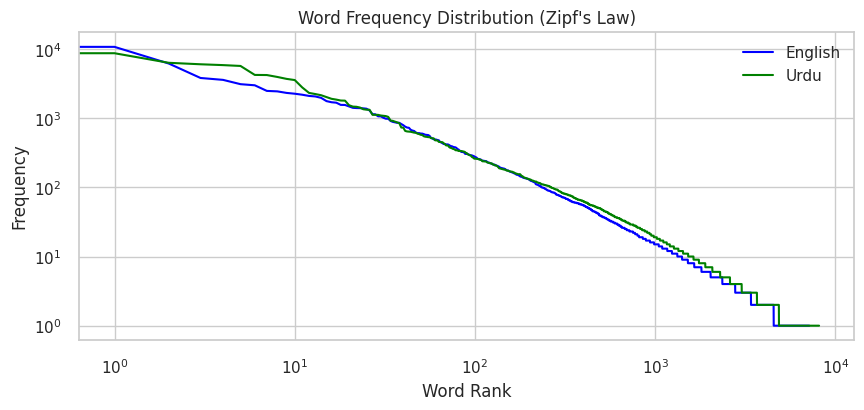

In [14]:
# ==========================================
# CELL 6: VOCABULARY THRESHOLDS & ZIPF'S LAW
# ==========================================
print("=" * 50)
print("VOCABULARY ANALYSIS (FOR TASK 3)")
print("=" * 50)

def analyze_vocabulary(text_series, name):
    words = ' '.join(text_series.astype(str).tolist()).split()
    word_counts = Counter(words)
    total_tokens = len(words)
    unique_types = len(word_counts)

    freq_df = pd.DataFrame.from_dict(word_counts, orient='index', columns=['count']).sort_values('count', ascending=False)
    freq_df['cumulative_coverage'] = freq_df['count'].cumsum() / total_tokens * 100

    num_words_95 = freq_df.index.get_loc((freq_df['cumulative_coverage'] >= 95).idxmax()) + 1
    singletons = sum(1 for w, c in word_counts.items() if c == 1)

    print(f"\n--- {name} Vocabulary Stats ---")
    print(f"Total Tokens (running words): {total_tokens:,}")
    print(f"Unique Types (Vocab Size): {unique_types:,}")
    print(f"Singletons (Freq=1): {singletons:,} ({(singletons/unique_types)*100:.1f}% of vocab)")
    print(f"Vocabulary size needed to cover 95% of text: {num_words_95:,} words")
    return freq_df

eng_vocab = analyze_vocabulary(df_clean[eng_col], "English")
urdu_vocab = analyze_vocabulary(df_clean[urdu_col], "Urdu")



# Zipf's Law Plot
plt.figure(figsize=(10, 4))
plt.plot(range(len(eng_vocab)), eng_vocab['count'], label='English', color='blue')
plt.plot(range(len(urdu_vocab)), urdu_vocab['count'], label='Urdu', color='green')
plt.yscale('log')
plt.xscale('log')
plt.title("Word Frequency Distribution (Zipf's Law)")
plt.xlabel("Word Rank")
plt.ylabel("Frequency")
plt.legend()
plt.savefig(PLOT_DIR / 'zipfs_law.png', dpi=150)
plt.show()